# import Dependencies

In [1]:
!pip install opendatasets --upgrade

pathanaliCollecting opendatasets


In [2]:
import opendatasets as od

In [3]:
od.download("https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: pathanali
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset


100%|██████████| 149M/149M [00:00<00:00, 729MB/s]  


In [6]:
import os
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageEnhance
import warnings
warnings.filterwarnings('ignore')

# Deep Learning Libraries
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Machine Learning Libraries
from sklearn.utils import shuffle
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Dataset Loading

In [7]:
# Directories for training and testing
train_dir = "/content/brain-tumor-mri-dataset/Training"
test_dir = "/content/brain-tumor-mri-dataset/Testing"

# load and shuffle the TRAIN data
train_paths = []
train_labels = []

for label in os.listdir(train_dir):
  # print(label)
  for image in os.listdir(os.path.join(train_dir, label)):
    train_paths.append(os.path.join(train_dir, label, image))
    train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

# load and shuffle the TEST data
test_paths = []
test_labels = []

for label in os.listdir(test_dir):
  # print(label)
  for image in os.listdir(os.path.join(test_dir, label)):
    test_paths.append(os.path.join(test_dir, label, image))
    test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

# Visualization of Data

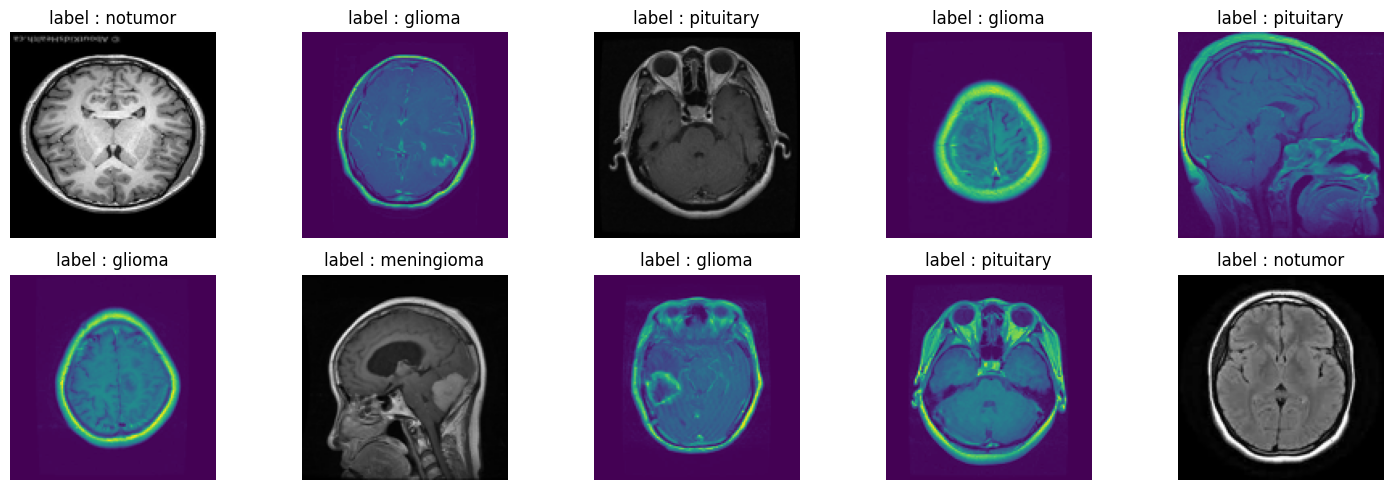

In [8]:
# select the 10 random indexis of images
random_indices = random.sample(range(len(train_paths)), 10)

# Now Create a figure and than display images
fig, axes = plt.subplots(2, 5, figsize=(15, 5))
axes = axes.ravel()
# loop through the random indices
for i, index in enumerate(random_indices):
  img_path = train_paths[index]
  img = Image.open(img_path)
  img = img.resize((128, 128))

  # display images
  axes[i].imshow(img)
  axes[i].axis("off")
  axes[i].set_title(f"label : {train_labels[index]}")

plt.tight_layout()
plt.show()

# Images Preprecessing

In [27]:
def augmented_image(image):
    # image: numpy array (H,W,3) or uint8 PIL -> returns float32 normalized array
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
    return np.array(image, dtype=np.float32) / 255.0

def open_images(paths):
    """
    Load a list of image file paths and return a numpy array with shape (N, H, W, 3).
    Ensures RGB, correct resizing, augmentation, and consistent batching.
    """
    images = []
    for path in paths:
        img = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))   # correct arg name
        if getattr(img, "mode", None) != "RGB":
            img = img.convert("RGB")
        arr = img_to_array(img)              # float32 array
        arr = augmented_image(arr)           # augment + normalize
        images.append(arr)
    if len(images) == 0:
        return np.zeros((0, IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.float32)
    return np.stack(images, axis=0)          # ensures shape (N, H, W, 3)

def encode_label(labels):
    """
    Encode a list of label strings into a numpy array of integers.
    Keeps stable, sorted class ordering.
    """
    unique_labels = sorted(os.listdir(train_dir))
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded, dtype=np.int32)

def datagen(paths, labels, batch_size=12, epochs=1):
    """
    Generator that yields (batch_images, batch_labels) where:
      - batch_images.shape[0] == batch_labels.shape[0]
      - images are float32 and normalized
      - labels is a numpy array of shape (batch_size,)
    Shuffles data each epoch to avoid ordering issues.
    """
    paths = np.array(paths)
    labels = np.array(labels)
    for _ in range(epochs):
        idx = np.arange(len(paths))
        np.random.shuffle(idx)
        for i in range(0, len(paths), batch_size):
            batch_idx = idx[i:i+batch_size]
            batch_paths = paths[batch_idx].tolist()
            batch_labels_raw = labels[batch_idx].tolist()
            batch_images = open_images(batch_paths)
            batch_labels = encode_label(batch_labels_raw)
            # Sanity check (optional): ensure shapes match
            if batch_images.shape[0] != batch_labels.shape[0]:
                raise ValueError(f"Batch size mismatch: images {batch_images.shape[0]} vs labels {batch_labels.shape[0]}")
            yield batch_images, batch_labels


In [28]:
# len(os.listdir(train_dir))

# Tarin the Model

In [29]:
IMAGE_SIZE = 128
# VGG16 base model
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights="imagenet")

# freeze all layers of the VGG16 base model first
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze the last 4 layers
for layer in base_model.layers[-4:]:
    layer.trainable = True

# Build the model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))
model.add(base_model)  # VGG16 model
model.add(Flatten())   # Flatten layer
model.add(Dropout(0.3))  # dropout
model.add(Dense(128, activation="relu"))
model.add(Dropout(0.3))
model.add(Dense(len(os.listdir(train_dir)), activation="softmax"))

# compile model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# set the parameters
batch_size = 20
steps = len(train_paths) // batch_size  # Use integer division
epochs = 7

print(f"Training on {len(train_paths)} images")
print(f"Steps per epoch: {steps}")
print(f"Number of classes: {len(os.listdir(train_dir))}")

# Train the model
history = model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
    steps_per_epoch=steps,
    epochs=epochs
)


Training on 5712 images
Steps per epoch: 285
Number of classes: 4
Epoch 1/7
285/285 ━━━━━━━━━━━━━━━━━━━━ 26s 58ms/step - accuracy: 0.7202 - loss: 0.6923
Epoch 2/7
285/285 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - accuracy: 0.8965 - loss: 0.2836
Epoch 3/7
285/285 ━━━━━━━━━━━━━━━━━━━━ 17s 59ms/step - accuracy: 0.9331 - loss: 0.1870
Epoch 4/7
285/285 ━━━━━━━━━━━━━━━━━━━━ 17s 58ms/step - accuracy: 0.9486 - loss: 0.1363
Epoch 5/7
285/285 ━━━━━━━━━━━━━━━━━━━━ 16s 57ms/step - accuracy: 0.9680 - loss: 0.0955
Epoch 6/7
285/285 ━━━━━━━━━━━━━━━━━━━━ 16s 57ms/step - accuracy: 0.9744 - loss: 0.0749
Epoch 7/7
285/285 ━━━━━━━━━━━━━━━━━━━━ 17s 58ms/step - accuracy: 0.9808 - loss: 0.0544


In [30]:
# IMAGE_SIZE = 128
# base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights="imagenet")

# # freeez the all layers of the VGG16 base model
# for layer in base_model.layers:
#   layer.trainable = False

# # Unfreeze the last 4 layers (or adjust as needed)
# for layer in base_model.layers[-4:]:
#     layer.trainable = True

# # set only the last few layers
# base_model.layers[-2:].trainable = True
# base_model.layers[-3:].trainable = True
# base_model.layers[-4:].trainable = True

# # Bulid the model
# model = Sequential()
# model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))
# model.add(base_model) # Vgg16 model jani
# model.add(Flatten()) # Flatten layers
# model.add(Dropout(0.3)) # dropout
# model.add(Dense(128, activation="relu"))
# model.add(Dropout(0.3))
# model.add(Dense(len(os.listdir(train_dir))), activation="softmax")

# # compile model
# model.compile(optimizer=Adam(learning_rate=0.0001), loss="sparse_categorical_crossentropy", metrics=["sparse_categorical_accuracy"])

# # set the parameters
# batch_size = 20
# steps = int(len(train_paths) / batch_size)
# epochs = 7

# # Train the model
# history = model.fit(
#     datagen(train_paths, train_labels, batch_size = batch_size, epochs = epochs),
#     steps_per_epoch=steps,
# )


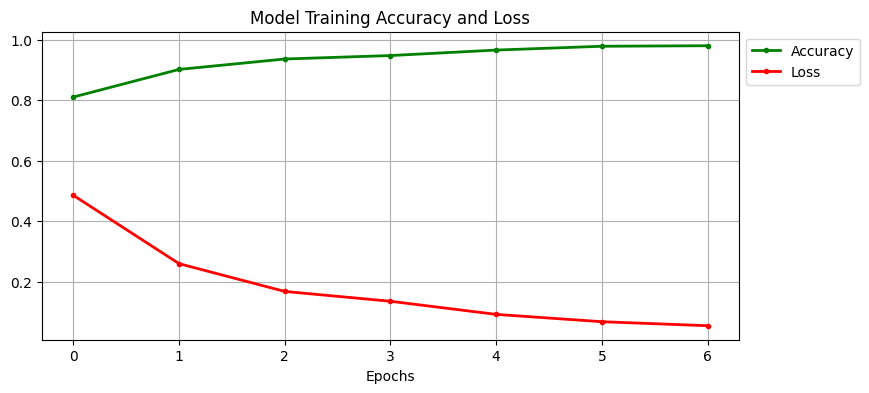

In [31]:
plt.figure(figsize=(9,4))
plt.grid(True)

# Accuracy
plt.plot(history.history["accuracy"], ".g-", linewidth=2)

# Loss
plt.plot(history.history["loss"], ".r-", linewidth=2)

plt.title("Model Training Accuracy and Loss")
plt.xlabel("Epochs")
plt.xticks(range(len(history.history["loss"])))
plt.legend(["Accuracy", "Loss"], loc="upper left", bbox_to_anchor=(1, 1))
plt.show()


In [32]:
test_images = open_images(test_paths)
test_labels_encoded = encode_label(test_labels)

test_predictions = model.predict(test_images)

print("Classification Report : ")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis = 1)))

print("Confusion Matrix : ")
print(confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis = 1)))


41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 216ms/step
Classification Report : 
              precision    recall  f1-score   support

           0       0.97      0.93      0.95       300
           1       0.93      0.94      0.94       306
           2       0.99      1.00      0.99       405
           3       0.98      0.99      0.99       300

    accuracy                           0.97      1311
   macro avg       0.97      0.97      0.97      1311
weighted avg       0.97      0.97      0.97      1311

Confusion Matrix : 
[[278  21   1   0]
 [  8 289   4   5]
 [  0   0 405   0]
 [  1   1   0 298]]


Confusion Matrix : 
[[278  21   1   0]
 [  8 289   4   5]
 [  0   0 405   0]
 [  1   1   0 298]]


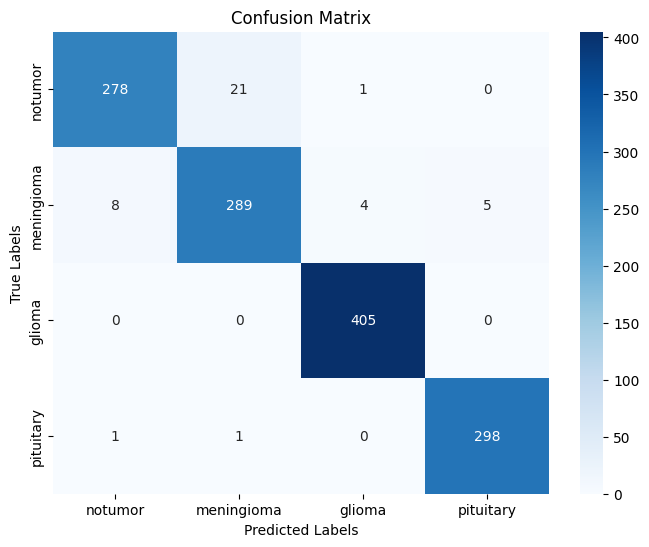

In [33]:
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis = 1))
print("Confusion Matrix : ")
print(conf_matrix)

plt.figure(figsize = (8, 6))
sns.heatmap(conf_matrix, annot = True, fmt = "d", cmap = "Blues", xticklabels = os.listdir(train_dir), yticklabels = os.listdir(train_dir))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

# Roc curve and AUC


In [34]:
# roc curve and AUC
fpr = dict()
tpr = dict()
roc_auc = dict()



# save the model

In [35]:
model.save("Brain tumor model.h5")

# Load the model

In [36]:
from tensorflow.keras.models import load_model
# load it
model = load_model("Brain tumor model.h5")

# MRI Tumor DEtection

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


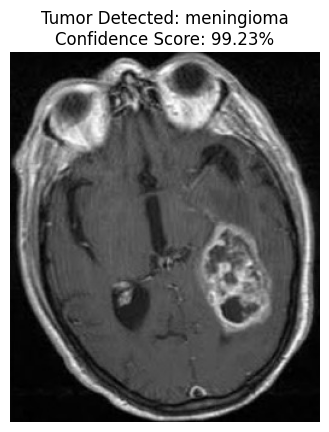

In [37]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

class_labels = ["glioma", "meningioma", "notumor", "pituitary"]

def detect_and_display(image_path, model):
    try:
        # Load and preprocess image
        img = load_img(image_path, target_size=(128, 128))
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = img_array / 255.0  # normalize if model trained on normalized images

        # Make prediction
        prediction = model.predict(img_array)
        predicted_class_index = np.argmax(prediction)
        confidence_score = prediction[0][predicted_class_index]

        # Determine the class
        if class_labels[predicted_class_index] == "notumor":
            result = "No Tumor"
        else:
            result = f"Tumor Detected: {class_labels[predicted_class_index]}"

        # Display image with result
        plt.imshow(load_img(image_path))
        plt.axis("off")
        plt.title(f"{result}\nConfidence Score: {confidence_score * 100:.2f}%")
        plt.show()

    except Exception as e:
        print("Error:", str(e))


# Example usage
image_path = "/content/brain-tumor-mri-dataset/Testing/meningioma/Te-meTr_0001.jpg"
detect_and_display(image_path, model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


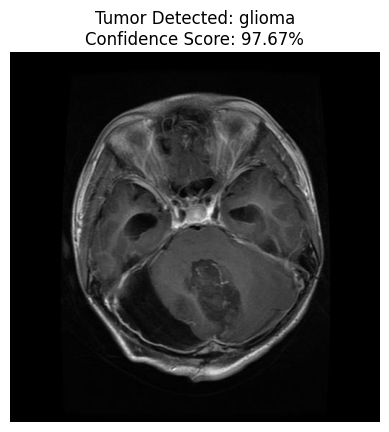

In [45]:
image_path = "/content/brain-tumor-mri-dataset/Testing/glioma/Te-glTr_0000.jpg"
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


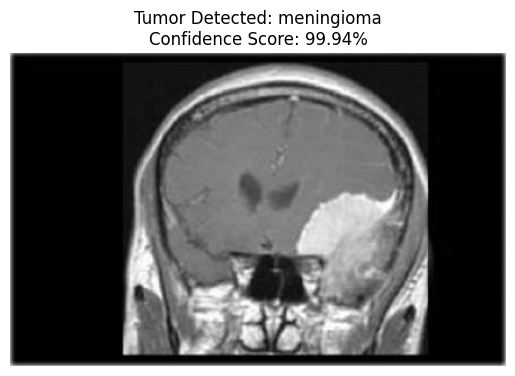

In [46]:
image_path = "/content/brain-tumor-mri-dataset/Testing/meningioma/Te-meTr_0000.jpg"
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


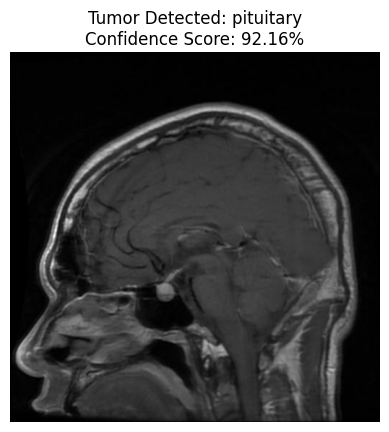

In [47]:
image_path = "/content/brain-tumor-mri-dataset/Testing/pituitary/Te-piTr_0006.jpg"
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


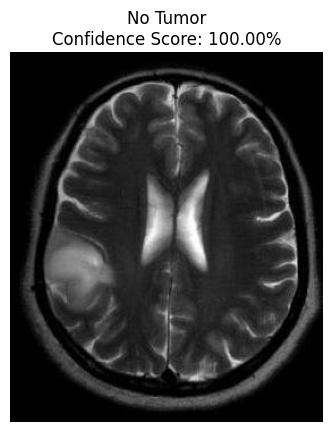

In [48]:
image_path = "/content/brain-tumor-mri-dataset/Testing/notumor/Te-no_0128.jpg"
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


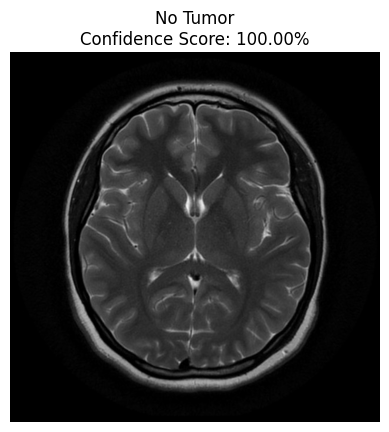

In [49]:
image_path = "/content/1 no.jpeg"
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


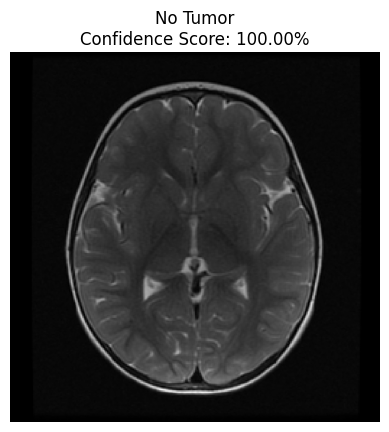

In [50]:
image_path = "/content/2 no.jpeg"
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


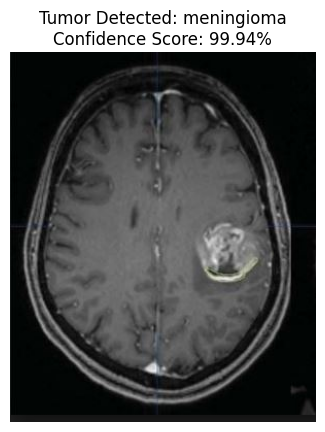

In [52]:
image_path = "/content/Y19.JPG"
detect_and_display(image_path, model)

In [ ]:
image_path = "/content/1 no.jpeg"
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


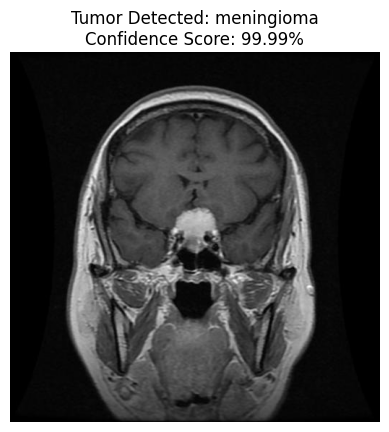

In [43]:
image_path = "/content/brain-tumor-mri-dataset/Testing/pituitary/Te-piTr_0002.jpg"
detect_and_display(image_path, model)

In [44]:
image_path = ""
detect_and_display(image_path, model)

Error: [Errno 2] No such file or directory: ''
